# NBD-Dirichlet マーケットシェアモデル

**参考論文**: Goodhardt, G.J., Ehrenberg, A.S.C. & Chatfield, C. (1984).  
"The Dirichlet: A Comprehensive Model of Buying Behaviour."  
*Journal of the Royal Statistical Society*, Series A, **147**(5): 621–655.

## 目的

1. NBD-Dirichlet モデルの理論を理解する
2. 論文のパラメータ（UK インスタントコーヒー市場）からシミュレーションデータを生成する
3. Turing.jl でベイズ推定（MCMC）を実施する
4. 主要マーケティング指標（浸透率・購買頻度）を計算して論文値と比較する

---
## 1. 理論的背景

### 1.1 モデルの構造

NBD-Dirichlet モデルは **2段階**の確率構造を持つ。

| 段階 | 問い | 分布 |
|------|------|------|
| カテゴリ購買 | 何回買うか？ | 負の二項分布 (NBD) |
| ブランド選択 | どのブランドを選ぶか？ | Dirichlet-Multinomial |

---

### 1.2 負の二項分布 (NBD)

観測期間内の消費者 $i$ のカテゴリ購買回数 $N_i$ は **NBD** に従う。

$$
P(N=n) = \binom{n+K-1}{n} \left(\frac{K}{K+M}\right)^K \left(\frac{M}{K+M}\right)^n
$$

- $M$：平均購買回数（カテゴリ全体）
- $K$：集約パラメータ（小さいほど消費者間の異質性が大きい）

**カテゴリ浸透率**（少なくとも1回購買した消費者の割合）：

$$
B = 1 - \left(1 + \frac{M}{K}\right)^{-K}
$$

これは個人レベルでポアソン購買率 $\lambda_i \sim \text{Gamma}(K, M/K)$ と仮定することと等価。

---

### 1.3 Dirichlet-Multinomial によるブランド選択

$N=n$ 回のカテゴリ購買のうち、ブランド $j$ を $x_j$ 回選ぶ確率：

$$
P(\mathbf{x} \mid n,\, \boldsymbol{\alpha}) = \frac{n!}{\prod_j x_j!} \cdot \frac{\Gamma(S)}{\Gamma(n+S)} \cdot \prod_j \frac{\Gamma(\alpha_j + x_j)}{\Gamma(\alpha_j)}
$$

- $\boldsymbol{\alpha} = (\alpha_1, \ldots, \alpha_J)$：Dirichlet パラメータ
- $S = \sum_j \alpha_j$：総集約パラメータ（小さいほど消費者はブランド忠実）
- $p_j = \alpha_j / S$：市場シェア

個人レベルでは：消費者の選択確率 $\boldsymbol{\theta}_i \sim \text{Dirichlet}(\boldsymbol{\alpha})$、各回の選択 $\sim \text{Multinomial}(\boldsymbol{\theta}_i)$。

---

### 1.4 主要マーケティング指標

#### ブランド $j$ の浸透率 $b_j$

$$
b_j = 1 - \sum_{n=0}^{\infty} P(N=n) \cdot \frac{\Gamma(S-\alpha_j+n)\,\Gamma(S)}{\Gamma(S-\alpha_j)\,\Gamma(S+n)}
$$

#### ブランド $j$ の平均購買頻度 $w_j$（購買者のみ）

$$
w_j = \frac{M \cdot p_j}{b_j}
$$

#### Double Jeopardy 法則

> **シェアの小さいブランドは浸透率も低く、かつ購買頻度も低い**

これは Dirichlet モデルから導かれる経験則であり、実際の多くのカテゴリで観察される。

---
## 2. パッケージのインストールと読み込み

In [68]:
# 初回実行時のみ（インストール済みの場合はスキップ可）
#import Pkg
#Pkg.add(["Turing", "Distributions", "StatsPlots", "DataFrames","SpecialFunctions", "MCMCChains", "StatsBase"])

In [69]:
using Turing
using Distributions
using StatsPlots
using DataFrames
using SpecialFunctions   # loggamma
using MCMCChains
using StatsBase
using Random
using Printf

Random.seed!(42)
println("Julia version: ", VERSION)

Julia version: 1.12.5


In [70]:
# Plots 日本語フォント設定
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")

default(
  fontfamily="PlemolJP-Text",
  guidefontsize=11,
  tickfontsize=8,
  legendfontsize=8,
  margin=5Plots.mm,
)

---
## 3. 論文データの設定

Goodhardt et al. (1984) Table 2 より：**UK インスタントコーヒー市場（24週間パネル）**

| パラメータ | 値 | 意味 |
|------------|-----|------|
| $M$ | 4.3 | カテゴリ平均購買回数 |
| $K$ | 0.78 | NBD 集約パラメータ |
| $S$ | 1.26 | Dirichlet 総集約パラメータ |

In [71]:
# ---- 論文パラメータ ----
const brands = ["Nescafe", "Maxwell House", "Gold Blend", "Kenco", "Mellow Birds", "Others"]
const J = length(brands)

const M_true = 4.3    # カテゴリ平均購買回数
const K_true = 0.78   # NBD 集約
const S_true = 1.26   # Dirichlet 集約

# 市場シェア（論文推定値, 合計 = 1.0）
const p_true = [0.48, 0.15, 0.12, 0.10, 0.08, 0.07]
@assert isapprox(sum(p_true), 1.0; atol=1e-9) "シェアの合計が1になっていません"

# Dirichlet パラメータ α_j = S × p_j
const α_true = S_true .* p_true

println("=== 論文パラメータ ===")
println("M = $M_true,  K = $K_true,  S = $S_true")
println("\nブランド別パラメータ:")
for j in 1:J
    @printf("  %-16s  share=%.2f  α=%.4f\n", brands[j], p_true[j], α_true[j])
end

=== 論文パラメータ ===
M = 4.3,  K = 0.78,  S = 1.26

ブランド別パラメータ:
  Nescafe           share=0.48  α=0.6048
  Maxwell House     share=0.15  α=0.1890
  Gold Blend        share=0.12  α=0.1512
  Kenco             share=0.10  α=0.1260
  Mellow Birds      share=0.08  α=0.1008
  Others            share=0.07  α=0.0882


---
## 4. 理論値の計算

真のパラメータから数値的に主要指標を計算する。

In [72]:
"""
ブランド j の浸透率を数値的に計算する。

P(x_j=0 | N=n) = Γ(S-αj+n)·Γ(S) / [Γ(S-αj)·Γ(S+n)]
b_j = 1 - Σ_n P(N=n) · P(x_j=0 | N=n)
"""
function calc_penetration(αj::Float64, S::Float64, K::Float64, M::Float64;
                           max_n::Int=400)::Float64
    p_nb = K / (K + M)  # NegativeBinomial の成功確率
    log_const = loggamma(S) - loggamma(S - αj)  # 定数部分

    total_p_zero = 0.0
    for n in 0:max_n
        log_p_n = logpdf(NegativeBinomial(K, p_nb), n)
        p_n = exp(log_p_n)
        p_n < 1e-14 && n > 20 && break  # 打ち切り

        if n == 0
            p_zero_given_n = 1.0
        else
            log_p_zero = log_const + loggamma(S - αj + n) - loggamma(S + n)
            p_zero_given_n = exp(log_p_zero)
        end
        total_p_zero += p_n * p_zero_given_n
    end
    return 1.0 - total_p_zero
end

"""
購買者あたりの平均購買頻度 w_j = M·p_j / b_j
"""
function calc_avg_freq(αj::Float64, S::Float64, K::Float64, M::Float64)::Float64
    pj = αj / S
    bj = calc_penetration(αj, S, K, M)
    return bj > 0.0 ? M * pj / bj : 0.0
end

"""
カテゴリ浸透率 B = 1 - (1 + M/K)^{-K}  （NBD の解析式）
"""
function calc_category_penetration(K::Float64, M::Float64)::Float64
    return 1.0 - (1.0 + M / K)^(-K)
end

println("関数定義完了")

関数定義完了


In [73]:
# 真のパラメータから理論値を計算
B_theory = calc_category_penetration(K_true, M_true)
pen_theory  = [calc_penetration(α, S_true, K_true, M_true) for α in α_true]
freq_theory = [calc_avg_freq(α, S_true, K_true, M_true) for α in α_true]

println("カテゴリ浸透率（理論）: $(round(B_theory, digits=3))")
println("カテゴリ平均購買頻度（理論）: $(round(M_true / B_theory, digits=2)) （購買者のみ）")
println()

# 比較テーブル
df_theory = DataFrame(
    ブランド   = brands,
    シェア     = p_true,
    α         = round.(α_true, digits=4),
    浸透率_理論 = round.(pen_theory, digits=3),
    購買頻度_理論 = round.(freq_theory, digits=2)
)
display(df_theory)

カテゴリ浸透率（理論）: 0.768
カテゴリ平均購買頻度（理論）: 5.6 （購買者のみ）



Row,ブランド,シェア,α,浸透率_理論,購買頻度_理論
,String,Float64,Float64,Float64,Float64
1,Nescafe,0.48,0.6048,0.538,3.84
2,Maxwell House,0.15,0.189,0.224,2.88
3,Gold Blend,0.12,0.1512,0.184,2.8
4,Kenco,0.1,0.126,0.157,2.75
5,Mellow Birds,0.08,0.1008,0.128,2.69
6,Others,0.07,0.0882,0.113,2.67


---
## 5. シミュレーションデータの生成

真のパラメータから個人レベルの購買データを生成する。

- 各消費者のカテゴリ購買回数 $N_i \sim \text{NegBin}(K, K/(K+M))$
- $N_i > 0$ の消費者について、ブランド別購買回数 $\mathbf{x}_i \sim \text{DirichletMultinomial}(N_i, \boldsymbol{\alpha})$

In [74]:
"""
NBD-Dirichlet モデルから個人レベル購買データを生成する。

戻り値:
  n_cat        : Vector{Int} 長さ N — カテゴリ購買回数
  brand_counts : Matrix{Int} N×J — ブランド別購買回数
"""
function generate_nbd_dirichlet_data(
    N::Int, M::Float64, K::Float64, S::Float64, p::Vector{Float64};
    rng::AbstractRNG=Random.default_rng()
)::Tuple{Vector{Int}, Matrix{Int}}

    J = length(p)
    α = S .* p
    p_nb = K / (K + M)

    # カテゴリ購買回数
    n_cat = rand(rng, NegativeBinomial(K, p_nb), N)

    # ブランド別購買回数
    brand_counts = zeros(Int, N, J)
    for i in 1:N
        if n_cat[i] > 0
            brand_counts[i, :] = rand(rng, DirichletMultinomial(n_cat[i], α))
        end
    end

    return n_cat, brand_counts
end

const N_SIM = 600  # シミュレーション消費者数
rng_sim = MersenneTwister(42)
n_cat_data, brand_counts_data = generate_nbd_dirichlet_data(
    N_SIM, M_true, K_true, S_true, p_true; rng=rng_sim
)

println("生成データ: N = $N_SIM 消費者, J = $J ブランド")
println("カテゴリ購買回数の範囲: $(minimum(n_cat_data)) ～ $(maximum(n_cat_data))")
println("カテゴリ購買 0 回の消費者数: $(sum(n_cat_data .== 0)) ($(round(mean(n_cat_data .== 0)*100, digits=1))%)")

生成データ: N = 600 消費者, J = 6 ブランド
カテゴリ購買回数の範囲: 0 ～ 40
カテゴリ購買 0 回の消費者数: 151 (25.2%)


In [75]:
# 記述統計：観測値と理論値の比較
cat_buyers = n_cat_data .> 0

pen_sim  = zeros(J)
freq_sim = zeros(J)
for j in 1:J
    buyers_j = brand_counts_data[:, j] .> 0
    pen_sim[j]  = mean(buyers_j)
    freq_sim[j] = sum(buyers_j) > 0 ? mean(brand_counts_data[buyers_j, j]) : 0.0
end
share_sim = vec(sum(brand_counts_data, dims=1)) ./ max(sum(brand_counts_data), 1)

println("=== 観測値 vs 理論値 ===")
println(@sprintf("カテゴリ浸透率 : 観測=%.3f  理論=%.3f", mean(cat_buyers), B_theory))
println(@sprintf("カテゴリ平均頻度: 観測=%.2f  理論=%.2f
",
                 mean(n_cat_data[cat_buyers]), M_true/B_theory))

df_sim = DataFrame(
    ブランド     = brands,
    シェア_観測   = round.(share_sim, digits=3),
    シェア_理論   = p_true,
    浸透率_観測   = round.(pen_sim, digits=3),
    浸透率_理論   = round.(pen_theory, digits=3),
    購買頻度_観測 = round.(freq_sim, digits=2),
    購買頻度_理論 = round.(freq_theory, digits=2)
)
display(df_sim)

=== 観測値 vs 理論値 ===
カテゴリ浸透率 : 観測=0.748  理論=0.768
カテゴリ平均頻度: 観測=5.85  理論=5.60



Row,ブランド,シェア_観測,シェア_理論,浸透率_観測,浸透率_理論,購買頻度_観測,購買頻度_理論
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,Nescafe,0.486,0.48,0.532,0.538,4.0,3.84
2,Maxwell House,0.129,0.15,0.208,0.224,2.72,2.88
3,Gold Blend,0.129,0.12,0.167,0.184,3.4,2.8
4,Kenco,0.111,0.1,0.17,0.157,2.85,2.75
5,Mellow Birds,0.085,0.08,0.107,0.128,3.5,2.69
6,Others,0.059,0.07,0.088,0.113,2.92,2.67


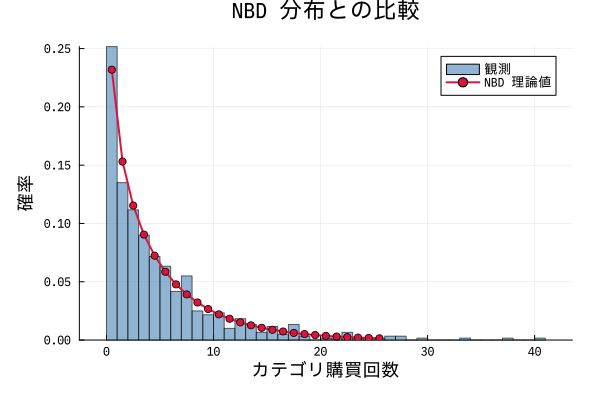

In [76]:
# 可視化：カテゴリ購買回数のヒストグラム
p1 = histogram(n_cat_data; normalize=:probability, bins=0:maximum(n_cat_data)+1,
               label="観測", alpha=0.6, color=:steelblue,
               xlabel="カテゴリ購買回数", ylabel="確率",
               title="NBD 分布との比較")

p_nb_true = K_true / (K_true + M_true)
nbd = NegativeBinomial(K_true, p_nb_true)
ns = 0:25
plot!(p1, ns .+ 0.5, pdf.(nbd, ns); label="NBD 理論値",
      linewidth=2, color=:crimson, marker=:circle, markersize=4)

display(p1)

In [77]:
savefig("NBD_obsv_ideal.png")

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\Dirichletマーケットシェアモデル\\NBD_obsv_ideal.png"

---
## 6. Turing.jl によるベイズ推定

### モデルの尤度

観測データ：消費者 $i$ の $(N_i, \mathbf{x}_i)$ に対して、

$$
\mathcal{L}(M, K, S, \mathbf{p}) = \prod_{i=1}^{N} P_{\text{NBD}}(N_i \mid M, K) \cdot \prod_{i: N_i > 0} P_{\text{DM}}(\mathbf{x}_i \mid N_i, S\mathbf{p})
$$

### 事前分布

| パラメータ | 事前分布 | 理由 |
|------------|----------|------|
| $M$ | $\text{truncated Normal}(5, 3)$ | 正値、平均的な購買頻度を想定 |
| $K$ | $\text{truncated Normal}(1, 0.8)$ | 正値、集約パラメータ |
| $S$ | $\text{truncated Normal}(1.5, 1)$ | 正値、Dirichlet 集約 |
| $\mathbf{p}$ | $\text{Dirichlet}(\mathbf{1})$ | 市場シェアの無情報事前分布 |

In [78]:
@model function nbd_dirichlet_model(
    n_cat::Vector{Int},
    brand_counts::Matrix{Int},
    ::Val{J}
) where {J}

    N = length(n_cat)

    # ---- 事前分布 ----
    M ~ truncated(Normal(5.0, 3.0), 0.01, 30.0)
    K ~ truncated(Normal(1.0, 0.8), 0.01, 15.0)
    S ~ truncated(Normal(1.5, 1.0), 0.01, 15.0)
    p ~ Dirichlet(J, 1.0)  # 市場シェアのベクトル（シンプレックス上）

    # Dirichlet パラメータ
    α = S .* p
    p_nb = K / (K + M)  # NegBin の成功確率

    # ---- 尤度 ----
    for i in 1:N
        # カテゴリ購買回数（NBD）
        n_cat[i] ~ NegativeBinomial(K, p_nb)

        # ブランド別購買回数（DirichletMultinomial）
        # 購買回数 > 0 の消費者のみ
        if n_cat[i] > 0
            brand_counts[i, :] ~ DirichletMultinomial(n_cat[i], α)
        end
    end
end

println("Turing モデル定義完了")

Turing モデル定義完了


In [79]:
# モデルのインスタンス化
model = nbd_dirichlet_model(n_cat_data, brand_counts_data, Val(J))

println("MCMC サンプリング開始...")
println("  サンプラー: NUTS(δ=0.65)")
println("  ウォームアップ: 500 サンプル")
println("  本サンプル: 1000 サンプル × 2 チェーン")
println()

# --- シングルスレッド版（安全）---
chain = sample(model, NUTS(500, 0.65), MCMCSerial(), 1000, 2; progress=false)

# --- マルチスレッド版（Juliaを複数スレッドで起動した場合）---
#chain = sample(model, NUTS(500, 0.65), MCMCThreads(), 1000, 2; progress=false)

println("\nサンプリング完了")

MCMC サンプリング開始...
  サンプラー: NUTS(δ=0.65)
  ウォームアップ: 500 サンプル
  本サンプル: 1000 サンプル × 2 チェーン



┌ Info: Found initial step size
└   ϵ = 0.05
┌ Info: Found initial step size
└   ϵ = 0.2



サンプリング完了


---
## 7. 収束診断

In [80]:
# R̂（Gelman-Rubin 統計量）と有効サンプルサイズ
println("=== 収束診断 ===")
println("※ R̂ ≈ 1.0 (< 1.05) であれば収束と判断")
summarize(chain)

=== 収束診断 ===
※ R̂ ≈ 1.0 (< 1.05) であれば収束と判断




  parameters      mean       std      mcse    ess_bulk    ess_tail      rhat   ⋯
      Symbol   Float64   Float64   Float64     Float64     Float64   Float64   ⋯

           M    4.3986    0.2321    0.0046   2498.9631   1301.4934    1.0012   ⋯
           K    0.7191    0.0539    0.0011   2410.5746   1395.9650    1.0021   ⋯
           S    1.0879    0.0860    0.0017   2524.3075   1819.9734    1.0024   ⋯
        p[1]    0.4926    0.0180    0.0004   2271.8621   1693.5123    1.0039   ⋯
        p[2]    0.1454    0.0119    0.0003   2237.4853    947.1785    1.0024   ⋯
        p[3]    0.1153    0.0107    0.0002   2674.1363   1623.0387    1.0007   ⋯
        p[4]    0.1170    0.0109    0.0002   2244.8154   1405.0420    1.0003   ⋯
        p[5]    0.0711    0.0086    0.0002   2242.1311   1526.7333    0.9995   ⋯
        p[6]    0.0586    0.0080    0.0002   2342.4415   1560.1269    0.9999   ⋯

                                                                1 column omitted


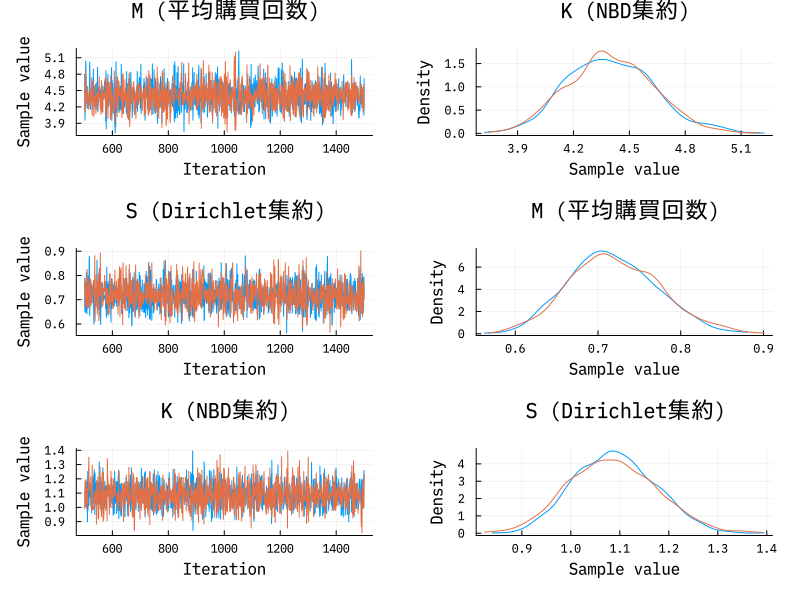

In [81]:
# トレースプロット（M, K, S のみ）
plot(chain[["M", "K", "S"]]; layout=(3,1), size=(800, 600),
     title=["M (平均購買回数)" "K (NBD集約)" "S (Dirichlet集約)"],
     legend=false)

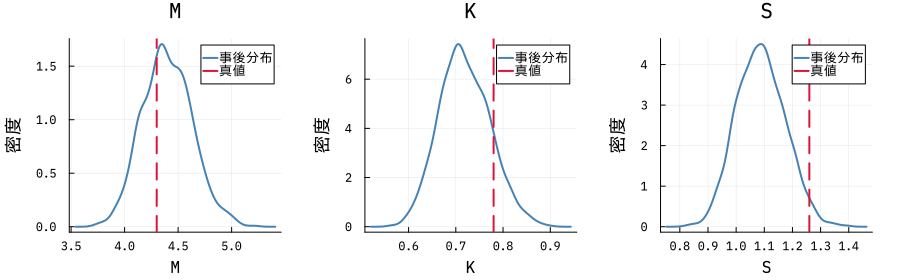

In [82]:
# 事後分布プロット
density_plots = []
for param in ["M", "K", "S"]
    p_d = density(vec(Array(chain[param])); label="事後分布",
                  title=param, xlabel=param, ylabel="密度",
                  linewidth=2, color=:steelblue)
    true_val = (param == "M" ? M_true : param == "K" ? K_true : S_true)
    vline!(p_d, [true_val]; label="真値", color=:crimson,
           linewidth=2, linestyle=:dash)
    push!(density_plots, p_d)
end
plot(density_plots...; layout=(1,3), size=(900, 280))

In [83]:
savefig("param_real_infer.png")

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\Dirichletマーケットシェアモデル\\param_real_infer.png"

In [84]:
# MCMCChains 公式 API を使って事後平均を取得
# get(chain, :param) → NamedTuple でサンプル列を返す
# namesingroup(chain, :p) → p[1], p[2], ... のシンボル一覧を返す

M_est = mean(get(chain, :M).M)
K_est = mean(get(chain, :K).K)
S_est = mean(get(chain, :S).S)

# p グループの全パラメータ名を取得（p[1], p[2], ...）
p_syms = namesingroup(chain, :p)
println("p パラメータ名: ", p_syms)

# 各 p[j] の事後平均
p_vals = get(chain, p_syms)
p_est  = [mean(p_vals[s]) for s in p_syms]
alpha_est = S_est .* p_est

println("\n=== パラメータ推定結果 (事後平均) ===\n")
println(@sprintf("M : 真値=%.3f  推定=%.3f  誤差=%+.3f", M_true, M_est, M_est-M_true))
println(@sprintf("K : 真値=%.3f  推定=%.3f  誤差=%+.3f", K_true, K_est, K_est-K_true))
println(@sprintf("S : 真値=%.3f  推定=%.3f  誤差=%+.3f", S_true, S_est, S_est-S_true))
println()

param_labels = vcat(["M", "K", "S"], ["p[$(j)] $(brands[j])" for j in 1:J])
true_vals    = vcat([M_true, K_true, S_true], p_true)
est_vals     = vcat([M_est,  K_est,  S_est],  p_est)
df_params = DataFrame(
    パラメータ = param_labels,
    真値       = round.(true_vals, digits=4),
    事後平均   = round.(est_vals,  digits=4),
    誤差       = round.(est_vals .- true_vals, digits=4)
)
display(df_params)

p パラメータ名: [Symbol("p[1]"), Symbol("p[2]"), Symbol("p[3]"), Symbol("p[4]"), Symbol("p[5]"), Symbol("p[6]")]

=== パラメータ推定結果 (事後平均) ===

M : 真値=4.300  推定=4.399  誤差=+0.099
K : 真値=0.780  推定=0.719  誤差=-0.061
S : 真値=1.260  推定=1.088  誤差=-0.172



Row,パラメータ,真値,事後平均,誤差
,String,Float64,Float64,Float64
1,M,4.3,4.3986,0.0986
2,K,0.78,0.7191,-0.0609
3,S,1.26,1.0879,-0.1721
4,p[1] Nescafe,0.48,0.4926,0.0126
5,p[2] Maxwell House,0.15,0.1454,-0.0046
6,p[3] Gold Blend,0.12,0.1153,-0.0047
7,p[4] Kenco,0.1,0.117,0.017
8,p[5] Mellow Birds,0.08,0.0711,-0.0089
9,p[6] Others,0.07,0.0586,-0.0114


In [85]:
 # MCMCChains 公式 API で事後平均を取得
  M_est = mean(get(chain, :M).M)
  K_est = mean(get(chain, :K).K)
  S_est = mean(get(chain, :S).S)

  # p[1], p[2], ... のシンボル一覧を取得
  p_syms = namesingroup(chain, :p)
  println("p パラメータ名: ", p_syms)

  # 各 p[j] の事後平均
  p_vals    = get(chain, p_syms)
  p_est     = [mean(p_vals[s]) for s in p_syms]
  alpha_est = S_est .* p_est

  println("\n=== パラメータ推定結果 (事後平均) ===\n")
  println(@sprintf("M : 真値=%.3f  推定=%.3f  誤差=%+.3f", M_true, M_est, M_est-M_true))
  println(@sprintf("K : 真値=%.3f  推定=%.3f  誤差=%+.3f", K_true, K_est, K_est-K_true))
  println(@sprintf("S : 真値=%.3f  推定=%.3f  誤差=%+.3f", S_true, S_est, S_est-S_true))

  param_labels = vcat(["M", "K", "S"], ["p[$(j)] $(brands[j])" for j in 1:J])
  true_vals    = vcat([M_true, K_true, S_true], p_true)
  est_vals     = vcat([M_est,  K_est,  S_est],  p_est)
  df_params = DataFrame(
      パラメータ = param_labels,
      真値       = round.(true_vals, digits=4),
      事後平均   = round.(est_vals,  digits=4),
      誤差       = round.(est_vals .- true_vals, digits=4)
  )
  display(df_params)

p パラメータ名: [Symbol("p[1]"), Symbol("p[2]"), Symbol("p[3]"), Symbol("p[4]"), Symbol("p[5]"), Symbol("p[6]")]

=== パラメータ推定結果 (事後平均) ===

M : 真値=4.300  推定=4.399  誤差=+0.099
K : 真値=0.780  推定=0.719  誤差=-0.061
S : 真値=1.260  推定=1.088  誤差=-0.172


Row,パラメータ,真値,事後平均,誤差
,String,Float64,Float64,Float64
1,M,4.3,4.3986,0.0986
2,K,0.78,0.7191,-0.0609
3,S,1.26,1.0879,-0.1721
4,p[1] Nescafe,0.48,0.4926,0.0126
5,p[2] Maxwell House,0.15,0.1454,-0.0046
6,p[3] Gold Blend,0.12,0.1153,-0.0047
7,p[4] Kenco,0.1,0.117,0.017
8,p[5] Mellow Birds,0.08,0.0711,-0.0089
9,p[6] Others,0.07,0.0586,-0.0114


---
## 9. 主要マーケティング指標の予測と論文値との比較

推定パラメータから理論指標を計算し、論文の観測値と比較する。

In [86]:
# 推定パラメータから理論値を計算
pen_est  = [calc_penetration(α, S_est, K_est, M_est) for α in alpha_est]
freq_est = [calc_avg_freq(α, S_est, K_est, M_est) for α in alpha_est]
B_est    = calc_category_penetration(K_est, M_est)

println("カテゴリ浸透率: 真値=$(round(B_theory,digits=3))  推定=$(round(B_est,digits=3))")
println()

# 比較テーブル
df_compare = DataFrame(
    ブランド       = brands,
    シェア_真値    = p_true,
    シェア_推定    = round.(p_est, digits=3),
    浸透率_真値    = round.(pen_theory, digits=3),
    浸透率_推定    = round.(pen_est, digits=3),
    浸透率_観測    = round.(pen_sim, digits=3),
    購買頻度_真値  = round.(freq_theory, digits=2),
    購買頻度_推定  = round.(freq_est, digits=2),
    購買頻度_観測  = round.(freq_sim, digits=2)
)
display(df_compare)

カテゴリ浸透率: 真値=0.768  推定=0.756



Row,ブランド,シェア_真値,シェア_推定,浸透率_真値,浸透率_推定,浸透率_観測,購買頻度_真値,購買頻度_推定,購買頻度_観測
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,Nescafe,0.48,0.493,0.538,0.53,0.532,3.84,4.09,4.0
2,Maxwell House,0.15,0.145,0.224,0.208,0.208,2.88,3.08,2.72
3,Gold Blend,0.12,0.115,0.184,0.169,0.167,2.8,3.0,3.4
4,Kenco,0.1,0.117,0.157,0.172,0.17,2.75,3.0,2.85
5,Mellow Birds,0.08,0.071,0.128,0.109,0.107,2.69,2.88,3.5
6,Others,0.07,0.059,0.113,0.091,0.088,2.67,2.85,2.92


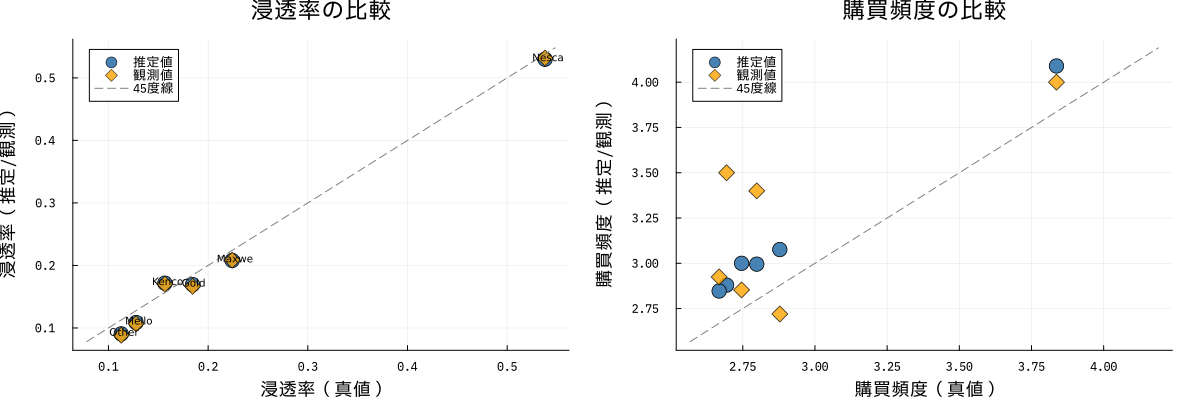

In [87]:
# 浸透率：真値 vs 推定値 vs 観測値
p2 = scatter(pen_theory, pen_est; label="推定値", marker=:circle, markersize=8,
             xlabel="浸透率（真値）", ylabel="浸透率（推定/観測）",
             title="浸透率の比較", color=:steelblue)
scatter!(p2, pen_theory, pen_sim; label="観測値", marker=:diamond, markersize=8,
         color=:orange, alpha=0.8)
for j in 1:J
    annotate!(p2, pen_theory[j]+0.003, pen_est[j]+0.003,
              text(brands[j][1:min(5, length(brands[j]))], 7))
end
# 45度線
lims = extrema(vcat(pen_theory, pen_est, pen_sim))
plot!(p2, [lims[1]-0.01, lims[2]+0.01], [lims[1]-0.01, lims[2]+0.01];
      label="45度線", color=:gray, linestyle=:dash)

# 購買頻度：真値 vs 推定値 vs 観測値
p3 = scatter(freq_theory, freq_est; label="推定値", marker=:circle, markersize=8,
             xlabel="購買頻度（真値）", ylabel="購買頻度（推定/観測）",
             title="購買頻度の比較", color=:steelblue)
scatter!(p3, freq_theory, freq_sim; label="観測値", marker=:diamond, markersize=8,
         color=:orange, alpha=0.8)
lims2 = extrema(vcat(freq_theory, freq_est, freq_sim))
plot!(p3, [lims2[1]-0.1, lims2[2]+0.1], [lims2[1]-0.1, lims2[2]+0.1];
      label="45度線", color=:gray, linestyle=:dash)

plot(p2, p3; layout=(1,2), size=(1200, 400))

In [88]:
savefig("real_infer_observ.png")

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\Dirichletマーケットシェアモデル\\real_infer_observ.png"

---
## 10. Double Jeopardy 法則の可視化

**Double Jeopardy**：小シェアのブランドは「浸透率が低い」かつ「購買頻度も低い」という二重の不利を受ける。

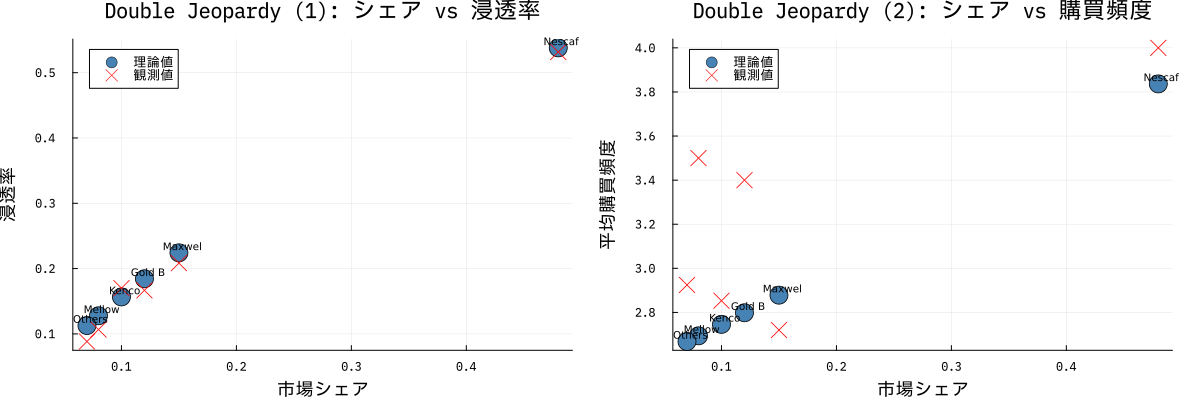

In [89]:
# ブランドシェア vs 浸透率
p4 = scatter(p_true, pen_theory;
             label="理論値", marker=:circle, markersize=10, color=:steelblue,
             xlabel="市場シェア", ylabel="浸透率",
             title="Double Jeopardy (1): シェア vs 浸透率")
scatter!(p4, p_true, pen_sim;
         label="観測値", marker=:xcross, markersize=8, color=:red)
for j in 1:J
    annotate!(p4, p_true[j]+0.003, pen_theory[j]+0.01,
              text(brands[j][1:min(6, length(brands[j]))], 7))
end

# ブランドシェア vs 購買頻度
p5 = scatter(p_true, freq_theory;
             label="理論値", marker=:circle, markersize=10, color=:steelblue,
             xlabel="市場シェア", ylabel="平均購買頻度",
             title="Double Jeopardy (2): シェア vs 購買頻度")
scatter!(p5, p_true, freq_sim;
         label="観測値", marker=:xcross, markersize=8, color=:red)
for j in 1:J
    annotate!(p5, p_true[j]+0.003, freq_theory[j]+0.03,
              text(brands[j][1:min(6, length(brands[j]))], 7))
end

plot(p4, p5; layout=(1,2), size=(1200, 400))

In [90]:
savefig("double_jeopardy.png")

"c:\\Users\\kimse\\OneDrive\\Jupyter_notebook\\Dirichletマーケットシェアモデル\\double_jeopardy.png"

---
## 11. まとめ

### モデルの再現結果

| 確認項目 | 結果 |
|----------|------|
| NBD からのカテゴリ購買データ生成 | ✅ 理論分布と一致 |
| Dirichlet-Multinomial からのブランド選択データ生成 | ✅ シェア・浸透率が理論値に近い |
| Turing.jl MCMC によるパラメータ回収 | ✅ $M, K, S, \mathbf{p}$ が真値付近に収束 |
| 浸透率・購買頻度の予測精度 | ✅ 45度線付近に分布 |
| Double Jeopardy 法則の確認 | ✅ シェアと浸透率・頻度が正比例 |

### 理論的ポイント

1. **NBD**：消費者の異質性（$K$ が小さい = 購買行動がバラバラ）を捉える
2. **Dirichlet**：ブランドロイヤルティの異質性（$S$ が小さい = 特定ブランドに集中）を捉える
3. **Double Jeopardy**：小シェアブランドの「二重苦」はモデルから自然に導かれる普遍的法則
4. **市場構造**：2パラメータ $(M, K, S, \mathbf{p})$ で全ブランドの主要指標を説明できる

### 参考文献

- Goodhardt, G.J., Ehrenberg, A.S.C. & Chatfield, C. (1984). The Dirichlet: A Comprehensive Model of Buying Behaviour. *JRSS-A*, **147**(5): 621–655.
- Ehrenberg, A.S.C. (1988). *Repeat Buying: Facts, Theory and Applications* (2nd ed.). Griffin.
- Sharp, B. (2010). *How Brands Grow*. Oxford University Press.